# Training CNN Complessa per FER-2013

Questo notebook allena una CNN custom piu' profonda della baseline `Training.ipynb`.

Obiettivo: provare a migliorare la generalizzazione su FER-2013 mantenendo input grayscale `48x48x1`, senza transfer learning.

## 1. Import e configurazione

In [1]:
from __future__ import annotations

import csv
import json
import time
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import (
    BackupAndRestore,
    CSVLogger,
    Callback,
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau,
    TerminateOnNaN,
)
from tensorflow.keras.layers import (
    Activation,
    BatchNormalization,
    Conv2D,
    Dense,
    Dropout,
    GlobalAveragePooling2D,
    Input,
    MaxPooling2D,
    SpatialDropout2D,
)
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

TRAIN_DIR = PROJECT_ROOT / "data" / "processed" / "train"
VALIDATION_DIR = PROJECT_ROOT / "data" / "processed" / "validation"
TEST_DIR = PROJECT_ROOT / "data" / "original" / "test"

EXPERIMENTS_DIR = PROJECT_ROOT / "experiments"
RESULTS_TABLES_DIR = PROJECT_ROOT / "results" / "tables"
RESULTS_FIGURES_DIR = PROJECT_ROOT / "results" / "figures"
RESULTS_PREDICTIONS_DIR = PROJECT_ROOT / "results" / "predictions"

CONFIG = {
    "model_name": "cnn_complex_v1",
    "batch_size": 64,
    "epochs": 150,
    "learning_rate": 5e-4,
    "weight_decay": 1e-4,
    "label_smoothing": 0.05,
    "early_stopping_patience": 22,
    "reduce_lr_patience": 6,
    "class_weight_max": 6.0,
    "seed": 42,
}

tf.keras.utils.set_random_seed(CONFIG["seed"])

for directory in [EXPERIMENTS_DIR, RESULTS_TABLES_DIR, RESULTS_FIGURES_DIR, RESULTS_PREDICTIONS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
experiment_dir = EXPERIMENTS_DIR / f"{timestamp}_cnn_complex_v1"
experiment_dir.mkdir(parents=True, exist_ok=False)

print("Project root:", PROJECT_ROOT)
print("Experiment dir:", experiment_dir)

Project root: C:\Users\ledoa\OneDrive\Documenti\GitHub\ProgettoDL_FaceFERward
Experiment dir: C:\Users\ledoa\OneDrive\Documenti\GitHub\ProgettoDL_FaceFERward\experiments\20260629_185100_cnn_complex_v1


## 2. Funzioni di supporto

In [2]:
def now() -> str:
    return datetime.now().strftime("%H:%M:%S")


class EpochTimingLogger(Callback):
    def on_train_begin(self, logs=None):
        self.epoch_times = []

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start_time = time.perf_counter()
        print(f"[{now()}] Epoch {epoch + 1} started")

    def on_epoch_end(self, epoch, logs=None):
        elapsed = time.perf_counter() - self.epoch_start_time
        self.epoch_times.append(elapsed)
        metrics = logs or {}
        compact_metrics = ", ".join(
            f"{key}={value:.4f}" for key, value in metrics.items() if isinstance(value, (int, float))
        )
        print(f"[{now()}] Epoch {epoch + 1} finished in {elapsed:.1f}s - {compact_metrics}")


def check_dataset_dirs() -> None:
    missing_dirs = [path for path in [TRAIN_DIR, VALIDATION_DIR, TEST_DIR] if not path.exists()]
    if missing_dirs:
        formatted = "\n".join(str(path) for path in missing_dirs)
        raise FileNotFoundError(
            "Cartelle dataset mancanti. Eseguire prima notebooks/Preprocessing.ipynb.\n"
            f"Missing:\n{formatted}"
        )


def save_json(path: Path, data: dict) -> None:
    with path.open("w", encoding="utf-8") as file:
        json.dump(data, file, indent=2)


def plot_training_curves(history_csv_path: Path, output_path: Path) -> None:
    history_df = pd.read_csv(history_csv_path)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for axis, metric, title in [
        (axes[0], "loss", "Loss"),
        (axes[1], "accuracy", "Accuracy"),
        (axes[2], "auc", "AUC"),
    ]:
        axis.plot(history_df[metric], label=f"train_{metric}")
        validation_metric = f"val_{metric}"
        if validation_metric in history_df:
            axis.plot(history_df[validation_metric], label=validation_metric)
        axis.set_title(title)
        axis.set_xlabel("Epoch")
        axis.grid(True, alpha=0.3)
        axis.legend()

    fig.tight_layout()
    fig.savefig(output_path, dpi=150)
    plt.show()


def plot_confusion_matrix(matrix: np.ndarray, labels: list[str], output_path: Path) -> None:
    fig, axis = plt.subplots(figsize=(9, 8))
    image = axis.imshow(matrix, interpolation="nearest", cmap="Blues")
    fig.colorbar(image, ax=axis)
    axis.set(
        xticks=np.arange(len(labels)),
        yticks=np.arange(len(labels)),
        xticklabels=labels,
        yticklabels=labels,
        ylabel="True label",
        xlabel="Predicted label",
        title="Confusion matrix - CNN complex",
    )
    plt.setp(axis.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    threshold = matrix.max() / 2.0 if matrix.size else 0
    for row in range(matrix.shape[0]):
        for col in range(matrix.shape[1]):
            axis.text(
                col,
                row,
                format(matrix[row, col], "d"),
                ha="center",
                va="center",
                color="white" if matrix[row, col] > threshold else "black",
            )

    fig.tight_layout()
    fig.savefig(output_path, dpi=150)
    plt.show()

## 3. Data generator e class weight

In [3]:
check_dataset_dirs()

train_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    rotation_range=15,
    width_shift_range=0.12,
    height_shift_range=0.12,
    shear_range=0.08,
    zoom_range=0.15,
    brightness_range=(0.80, 1.20),
    horizontal_flip=True,
    fill_mode="nearest",
)
eval_datagen = ImageDataGenerator(rescale=1.0 / 255.0)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(48, 48),
    color_mode="grayscale",
    class_mode="categorical",
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    seed=CONFIG["seed"],
)
validation_generator = eval_datagen.flow_from_directory(
    VALIDATION_DIR,
    target_size=(48, 48),
    color_mode="grayscale",
    class_mode="categorical",
    batch_size=CONFIG["batch_size"],
    shuffle=False,
)
test_generator = eval_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(48, 48),
    color_mode="grayscale",
    class_mode="categorical",
    batch_size=CONFIG["batch_size"],
    shuffle=False,
)

classes = np.unique(train_generator.classes)
raw_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_generator.classes,
)
class_weights = {
    int(label): float(min(weight, CONFIG["class_weight_max"]))
    for label, weight in zip(classes, raw_weights)
}

print("Class indices:", train_generator.class_indices)
print("Class weights:", class_weights)

Found 32155 images belonging to 7 classes.
Found 5741 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.
Class indices: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}
Class weights: {0: 1.0192082157913087, 1: 6.0, 2: 1.0012143479885416, 3: 0.5697806286990112, 4: 0.8261819116135662, 5: 0.8495600940579672, 6: 1.2925074362890907}


## 4. Architettura CNN complessa

In [4]:
def conv_block(model: Sequential, filters: int, dropout_rate: float, weight_decay: float) -> None:
    kernel_regularizer = regularizers.l2(weight_decay)
    model.add(Conv2D(filters, (3, 3), padding="same", kernel_regularizer=kernel_regularizer))
    model.add(BatchNormalization())
    model.add(Activation("relu"))
    model.add(Conv2D(filters, (3, 3), padding="same", kernel_regularizer=kernel_regularizer))
    model.add(BatchNormalization())
    model.add(Activation("relu"))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(SpatialDropout2D(dropout_rate))


def build_complex_cnn(num_classes: int) -> Sequential:
    weight_decay = CONFIG["weight_decay"]
    kernel_regularizer = regularizers.l2(weight_decay)

    model = Sequential(name="cnn_complex_v1")
    model.add(Input(shape=(48, 48, 1)))

    for filters, dropout_rate in [
        (32, 0.08),
        (64, 0.12),
        (128, 0.18),
        (256, 0.24),
    ]:
        conv_block(model, filters, dropout_rate, weight_decay)

    model.add(Conv2D(512, (3, 3), padding="same", kernel_regularizer=kernel_regularizer))
    model.add(BatchNormalization())
    model.add(Activation("relu"))
    model.add(Conv2D(512, (3, 3), padding="same", kernel_regularizer=kernel_regularizer))
    model.add(BatchNormalization())
    model.add(Activation("relu"))
    model.add(GlobalAveragePooling2D())

    model.add(Dense(512, kernel_regularizer=kernel_regularizer))
    model.add(BatchNormalization())
    model.add(Activation("relu"))
    model.add(Dropout(0.50))
    model.add(Dense(256, kernel_regularizer=kernel_regularizer))
    model.add(BatchNormalization())
    model.add(Activation("relu"))
    model.add(Dropout(0.40))
    model.add(Dense(num_classes, activation="softmax"))

    optimizer = tf.keras.optimizers.AdamW(
        learning_rate=CONFIG["learning_rate"],
        weight_decay=CONFIG["weight_decay"],
        clipnorm=1.0,
    )
    model.compile(
        optimizer=optimizer,
        loss=CategoricalCrossentropy(label_smoothing=CONFIG["label_smoothing"]),
        metrics=["accuracy", tf.keras.metrics.AUC(name="auc")],
    )
    return model


modelCNNComplex = build_complex_cnn(train_generator.num_classes)
modelCNNComplex.summary()

Model: "cnn_complex_v1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d               │ (None, 24, 24, 32)     │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_1             │ (None, 12, 12, 64)     │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 5,118,439 (19.53 MB)

 Trainable params: 5,112,935 (19.50 MB)

 Non-trainable params: 5,504 (21.50 KB)

## 5. Salvataggio configurazione

In [5]:
run_config = {
    "model_name": CONFIG["model_name"],
    "timestamp": timestamp,
    "input_shape": [48, 48, 1],
    "batch_size": CONFIG["batch_size"],
    "epochs": CONFIG["epochs"],
    "optimizer": "AdamW",
    "learning_rate": CONFIG["learning_rate"],
    "weight_decay": CONFIG["weight_decay"],
    "label_smoothing": CONFIG["label_smoothing"],
    "loss": "categorical_crossentropy",
    "metrics": ["accuracy", "auc"],
    "class_weight": {str(key): value for key, value in class_weights.items()},
    "class_weight_max": CONFIG["class_weight_max"],
    "train_dir": str(TRAIN_DIR.relative_to(PROJECT_ROOT)),
    "validation_dir": str(VALIDATION_DIR.relative_to(PROJECT_ROOT)),
    "test_dir": str(TEST_DIR.relative_to(PROJECT_ROOT)),
    "output_dir": str(experiment_dir.relative_to(PROJECT_ROOT)),
    "num_params": int(modelCNNComplex.count_params()),
    "architecture": "VGG-style CNN: 5 convolutional stages, 2 conv layers per stage, BatchNorm, SpatialDropout2D, GlobalAveragePooling2D, Dense head.",
}

save_json(experiment_dir / "config.json", run_config)

## 6. Training lungo

[18:51:30] Training started. Output: C:\Users\ledoa\OneDrive\Documenti\GitHub\ProgettoDL_FaceFERward\experiments\20260629_185100_cnn_complex_v1
[18:51:30] Epoch 1 started
Epoch 1/150
503/503 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step - accuracy: 0.1743 - auc: 0.5613 - loss: 2.2526
Epoch 1: val_loss improved from None to 2.13973, saving model to C:\Users\ledoa\OneDrive\Documenti\GitHub\ProgettoDL_FaceFERward\experiments\20260629_185100_cnn_complex_v1\model.keras

Epoch 1: finished saving model to C:\Users\ledoa\OneDrive\Documenti\GitHub\ProgettoDL_FaceFERward\experiments\20260629_185100_cnn_complex_v1\model.keras
[18:55:15] Epoch 1 finished in 224.6s - accuracy=0.1743, auc=0.5613, loss=2.2526, val_accuracy=0.1942, val_auc=0.6080, val_loss=2.1397, learning_rate=0.0005
503/503 ━━━━━━━━━━━━━━━━━━━━ 225s 433ms/step - accuracy: 0.1743 - auc: 0.5613 - loss: 2.2526 - val_accuracy: 0.1942 - val_auc: 0.6080 - val_loss: 2.1397 - learning_rate: 5.0000e-04
[18:55:15] Epoch 2 started
Epoch 2/150
503/503 ━━━

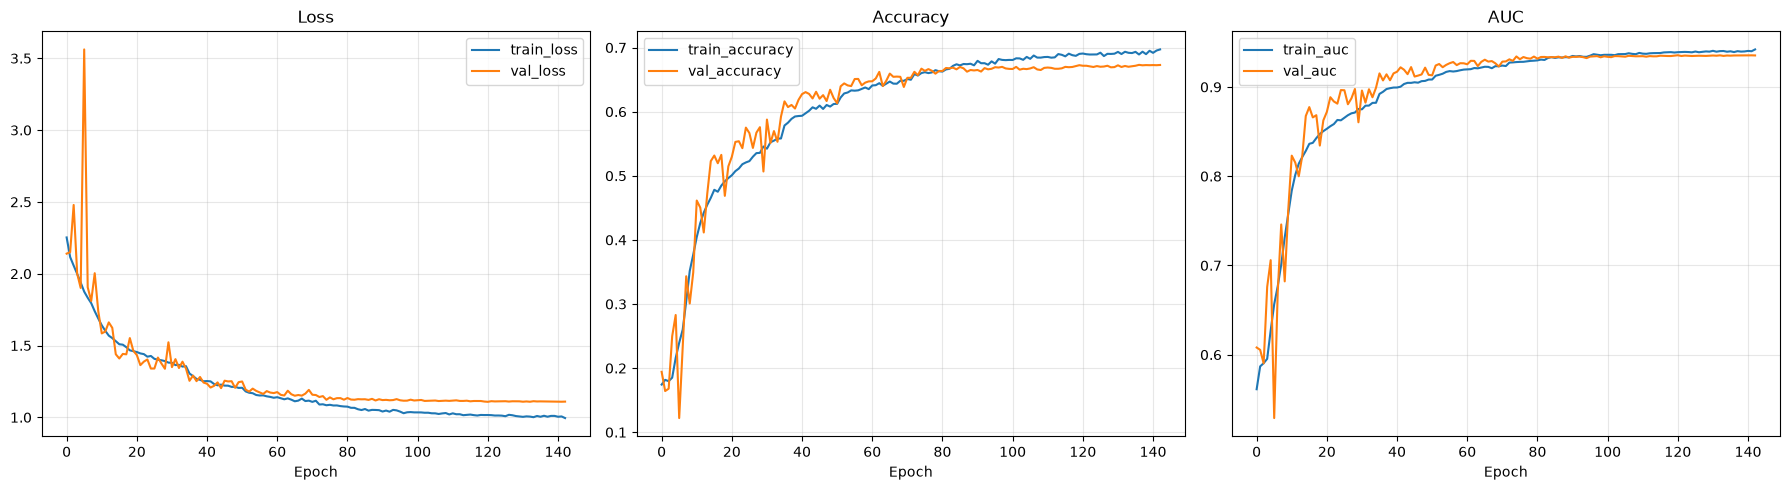

Modello: cnn_complex_v1
Data: 20260629_185100
Epoche completate: 143/150
Migliore val_loss: 1.1080 all'epoca 121
Training time seconds: 17964.0



In [6]:
best_model_path = experiment_dir / "model.keras"
history_csv_path = experiment_dir / "training_history.csv"

callbacks = [
    TerminateOnNaN(),
    BackupAndRestore(backup_dir=str(experiment_dir / "backup")),
    EarlyStopping(
        monitor="val_loss",
        patience=CONFIG["early_stopping_patience"],
        restore_best_weights=True,
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=CONFIG["reduce_lr_patience"],
        min_lr=1e-7,
        verbose=1,
    ),
    ModelCheckpoint(str(best_model_path), monitor="val_loss", save_best_only=True, verbose=1),
    CSVLogger(str(history_csv_path), separator=",", append=False),
    EpochTimingLogger(),
]

print(f"[{now()}] Training started. Output: {experiment_dir}")
train_start = time.perf_counter()

history = modelCNNComplex.fit(
    train_generator,
    epochs=CONFIG["epochs"],
    validation_data=validation_generator,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1,
)

train_time_seconds = time.perf_counter() - train_start

if not best_model_path.exists():
    modelCNNComplex.save(best_model_path)

best_model = tf.keras.models.load_model(best_model_path)

best_epoch = int(np.argmin(history.history["val_loss"]) + 1)
best_val_loss = float(np.min(history.history["val_loss"]))

training_log = (
    f"Modello: cnn_complex_v1\n"
    f"Data: {timestamp}\n"
    f"Epoche completate: {len(history.history['loss'])}/{CONFIG['epochs']}\n"
    f"Migliore val_loss: {best_val_loss:.4f} all'epoca {best_epoch}\n"
    f"Training time seconds: {train_time_seconds:.1f}\n"
)
(experiment_dir / "training_log.txt").write_text(training_log, encoding="utf-8")

training_curves_path = RESULTS_FIGURES_DIR / f"{experiment_dir.name}_training_curves.png"
plot_training_curves(history_csv_path, training_curves_path)

print(training_log)

## 7. Valutazione finale e salvataggio risultati

113/113 ━━━━━━━━━━━━━━━━━━━━ 9s 73ms/step - accuracy: 0.6704 - auc: 0.9312 - loss: 1.1357
113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step


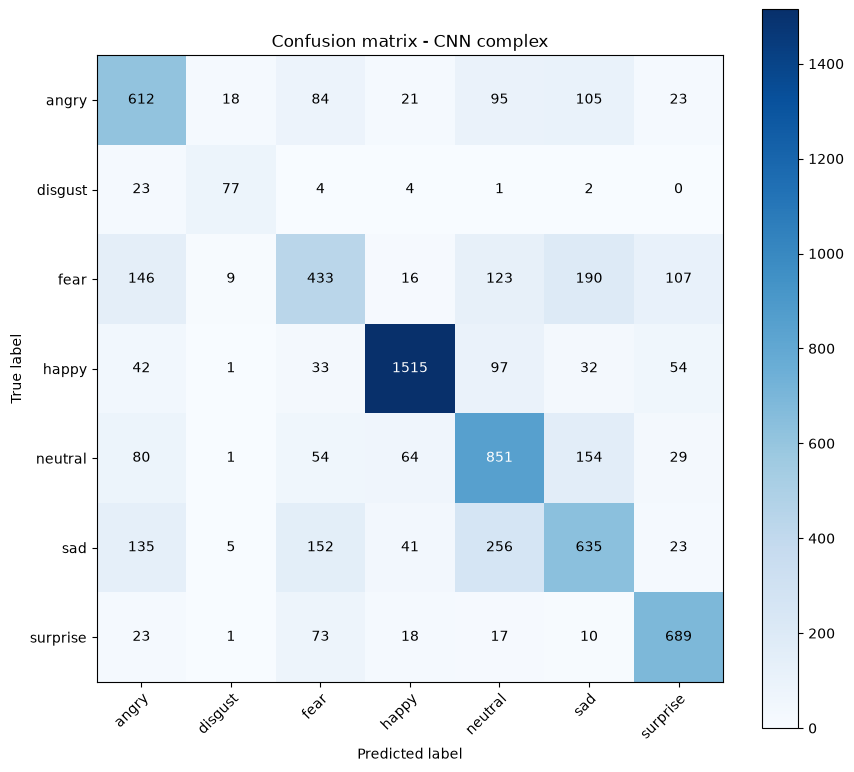

Test loss: 1.1357
Test accuracy: 0.6704
Test AUC: 0.9312
Macro F1: 0.6567
Weighted F1: 0.6681
Inference time: 2.2801 ms/image

              precision    recall  f1-score   support

       angry       0.58      0.64      0.61       958
     disgust       0.69      0.69      0.69       111
        fear       0.52      0.42      0.47      1024
       happy       0.90      0.85      0.88      1774
     neutral       0.59      0.69      0.64      1233
         sad       0.56      0.51      0.53      1247
    surprise       0.74      0.83      0.78       831

    accuracy                           0.67      7178
   macro avg       0.66      0.66      0.66      7178
weighted avg       0.67      0.67      0.67      7178




In [7]:
test_start = time.perf_counter()
test_loss, test_accuracy, test_auc = best_model.evaluate(test_generator, verbose=1)
y_pred_proba = best_model.predict(test_generator, verbose=1)
inference_time_ms = ((time.perf_counter() - test_start) / max(test_generator.samples, 1)) * 1000

y_true = test_generator.classes
y_pred = np.argmax(y_pred_proba, axis=1)
target_names = list(test_generator.class_indices.keys())

report_dict = classification_report(
    y_true,
    y_pred,
    target_names=target_names,
    output_dict=True,
    zero_division=0,
)
report_text = classification_report(
    y_true,
    y_pred,
    target_names=target_names,
    zero_division=0,
)
conf_matrix = confusion_matrix(y_true, y_pred)

report_csv_path = RESULTS_TABLES_DIR / f"{experiment_dir.name}_classification_report.csv"
confusion_csv_path = RESULTS_TABLES_DIR / f"{experiment_dir.name}_confusion_matrix.csv"
predictions_csv_path = RESULTS_PREDICTIONS_DIR / f"{experiment_dir.name}_test_predictions.csv"
confusion_fig_path = RESULTS_FIGURES_DIR / f"{experiment_dir.name}_confusion_matrix.png"

pd.DataFrame(report_dict).transpose().to_csv(report_csv_path)
pd.DataFrame(conf_matrix, index=target_names, columns=target_names).to_csv(confusion_csv_path)
plot_confusion_matrix(conf_matrix, target_names, confusion_fig_path)

prediction_df = pd.DataFrame(y_pred_proba, columns=[f"proba_{name}" for name in target_names])
prediction_df.insert(0, "filename", test_generator.filenames)
prediction_df.insert(1, "true_label", [target_names[index] for index in y_true])
prediction_df.insert(2, "predicted_label", [target_names[index] for index in y_pred])
prediction_df.to_csv(predictions_csv_path, index=False)

macro_f1 = float(report_dict["macro avg"]["f1-score"])
weighted_f1 = float(report_dict["weighted avg"]["f1-score"])
model_size_mb = best_model_path.stat().st_size / (1024 * 1024)

results_text = (
    f"Test loss: {test_loss:.4f}\n"
    f"Test accuracy: {test_accuracy:.4f}\n"
    f"Test AUC: {test_auc:.4f}\n"
    f"Macro F1: {macro_f1:.4f}\n"
    f"Weighted F1: {weighted_f1:.4f}\n"
    f"Inference time: {inference_time_ms:.4f} ms/image\n\n"
    f"{report_text}\n"
)
(experiment_dir / "test_results.txt").write_text(results_text, encoding="utf-8")

print(results_text)

## 8. Aggiornamento tabella confronto modelli

In [8]:
comparison_path = RESULTS_TABLES_DIR / "models_comparison.csv"
fieldnames = [
    "experiment_name",
    "model_name",
    "base_model",
    "pretrained_weights",
    "input_size",
    "test_accuracy",
    "macro_f1",
    "weighted_f1",
    "test_auc",
    "num_params",
    "model_size_mb",
    "train_time_seconds",
    "inference_time_ms_per_image",
    "experiment_dir",
]
row = {
    "experiment_name": experiment_dir.name,
    "model_name": CONFIG["model_name"],
    "base_model": "Custom CNN complex",
    "pretrained_weights": "none",
    "input_size": "48x48x1",
    "test_accuracy": float(test_accuracy),
    "macro_f1": macro_f1,
    "weighted_f1": weighted_f1,
    "test_auc": float(test_auc),
    "num_params": int(modelCNNComplex.count_params()),
    "model_size_mb": model_size_mb,
    "train_time_seconds": train_time_seconds,
    "inference_time_ms_per_image": inference_time_ms,
    "experiment_dir": str(experiment_dir.relative_to(PROJECT_ROOT)),
}

existing_rows = []
if comparison_path.exists():
    with comparison_path.open("r", newline="", encoding="utf-8") as file:
        existing_rows = list(csv.DictReader(file))

existing_rows = [item for item in existing_rows if item.get("experiment_name") != experiment_dir.name]
existing_rows.append(row)

with comparison_path.open("w", newline="", encoding="utf-8") as file:
    writer = csv.DictWriter(file, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(existing_rows)

print("Tabella confronto aggiornata:", comparison_path)

Tabella confronto aggiornata: C:\Users\ledoa\OneDrive\Documenti\GitHub\ProgettoDL_FaceFERward\results\tables\models_comparison.csv
